# AI Student Performance Analysis Using Generative AI

## Abstract
This project analyzes the relationship between Generative AI usage, study habits, prompt engineering skills, and student academic performance. The workflow follows the CRISP-DM methodology and includes data cleaning, exploratory data analysis, feature engineering, model building, and evaluation.

## CRISP-DM Methodology
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation


## Business Understanding

**Problem:** Generative AI tools (e.g. ChatGPT, Copilot) are now widely used by students, but it is unclear whether heavy reliance on them helps or hurts academic performance and long-term skill retention.

**Goal:** Quantify the relationship between GenAI usage patterns (hours/week, prompt engineering skill, primary use case, paid subscription status) and student outcomes (change in GPA from Pre- to Post-Semester, and Skill Retention Score), and build a model that can predict Post-Semester GPA from these behavioral and academic features.

**Success criteria:** A regression model with interpretable coefficients/feature importance that explains a meaningful share of variance in Post_Semester_GPA (measured via R²), along with clear insight into which behaviors are associated with better or worse outcomes.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Data Understanding

This section loads the dataset and explores its structure, dimensions, columns, and data types.

In [6]:
# Load dataset (place the CSV in the same folder as this notebook)
df = pd.read_csv('AI_Student_performance_dataset.csv')

Understand the dataset

In [7]:
print("Rows and Columns:", df.shape)

Rows and Columns: (51000, 16)


In [8]:
#view sample records
print(df.head())

   Student_ID Major_Category Year_of_Study  Pre_Semester_GPA  \
0      100001        Medical     Sophomore             3.192   
1      100002     Humanities     Sophomore             3.683   
2      100003           STEM        Senior             3.450   
3      100004        Medical      Freshman             2.878   
4      100005        Medical        Junior             3.915   

   Weekly_GenAI_Hours           Primary_Use_Case Prompt_Engineering_Skill  \
0                7.78       Copywriting/Drafting                 Advanced   
1               22.29  Debugging/Troubleshooting             Intermediate   
2                3.57        Summarizing_Reading                 Beginner   
3               11.37       Copywriting/Drafting             Intermediate   
4               28.16                   Ideation                 Beginner   

   Tool_Diversity  Paid_Subscription  Traditional_Study_Hours  \
0               4              False                     7.77   
1               2     

In [9]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  51000 non-null  int64  
 1   Major_Category              51000 non-null  str    
 2   Year_of_Study               51000 non-null  str    
 3   Pre_Semester_GPA            49470 non-null  float64
 4   Weekly_GenAI_Hours          49476 non-null  float64
 5   Primary_Use_Case            51000 non-null  str    
 6   Prompt_Engineering_Skill    49470 non-null  str    
 7   Tool_Diversity              51000 non-null  int64  
 8   Paid_Subscription           51000 non-null  bool   
 9   Traditional_Study_Hours     49475 non-null  float64
 10  Perceived_AI_Dependency     51000 non-null  int64  
 11  Institutional_Policy        51000 non-null  str    
 12  Anxiety_Level_During_Exams  51000 non-null  int64  
 13  Post_Semester_GPA           51000 non-null

## Data Cleaning

Data quality issues such as missing values, duplicates, inconsistent formatting, and invalid entries are identified and corrected.

In [10]:
(df.dataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
}))

AttributeError: 'DataFrame' object has no attribute 'dataFrame'

Student_ID                    0.000000
Major_Category                0.000000
Year_of_Study                 0.000000
Pre_Semester_GPA              3.000000
Weekly_GenAI_Hours            2.988235
Primary_Use_Case              0.000000
Prompt_Engineering_Skill      3.000000
Tool_Diversity                0.000000
Paid_Subscription             0.000000
Traditional_Study_Hours       2.990196
Perceived_AI_Dependency       0.000000
Institutional_Policy          0.000000
Anxiety_Level_During_Exams    0.000000
Post_Semester_GPA             0.000000
Skill_Retention_Score         2.984314
Burnout_Risk_Level            0.000000
dtype: float64

In [ ]:
df.duplicated().sum()

636

In [ ]:
df.drop_duplicates(inplace=True)
print(df)

       Student_ID Major_Category Year_of_Study  Pre_Semester_GPA  \
0          100001        Medical     Sophomore             3.192   
1          100002     Humanities     Sophomore             3.683   
2          100003           STEM        Senior             3.450   
3          100004        Medical      Freshman             2.878   
4          100005        Medical        Junior             3.915   
...           ...            ...           ...               ...   
50982      148706           STEM        Senior             2.246   
50984      118786           STEM      Freshman             3.067   
50987      133986        Medical     Sophomore             3.203   
50988      111626        Medical      Freshman             3.267   
50992      143512           STEM      Freshman             3.312   

       Weekly_GenAI_Hours           Primary_Use_Case Prompt_Engineering_Skill  \
0                    7.78       Copywriting/Drafting                 Advanced   
1                   2

In [ ]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50364.000000,48834.000000,48840.000000,50364.000000,48840.000000,50364.000000,50364.000000,50364.000000,48842.000000
mean,124999.180208,3.198821,10.462221,3.000298,12.194850,3.002343,5.512310,3.238701,74.902015
std,14436.998487,0.392750,9.828805,1.411649,5.409213,1.414001,2.871882,0.431002,15.163235
min,100001.000000,1.415000,0.020000,1.000000,0.000000,1.000000,1.000000,1.077000,11.590000
25%,112498.750000,2.933000,4.870000,2.000000,9.300000,2.000000,3.000000,2.943000,64.870000
50%,124996.500000,3.203000,8.480000,3.000000,12.010000,3.000000,6.000000,3.248000,75.000000
75%,137505.250000,3.472000,13.550000,4.000000,14.720000,4.000000,8.000000,3.552000,85.200000
max,150000.000000,4.000000,149.811876,5.000000,99.654631,5.000000,10.000000,4.000000,199.825455


In [ ]:
df.describe(include='object')

C:\Users\Prameel\AppData\Local\Temp\ipykernel_8396\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Major_Category,Year_of_Study,Primary_Use_Case,Prompt_Engineering_Skill,Institutional_Policy,Burnout_Risk_Level
count,50364,50364,50364,48834,50364,50364
unique,7,8,8,3,3,4
top,STEM,Sophomore,Summarizing_Reading,Intermediate,Strict_Ban,Low
freq,12700,12606,12450,19695,16869,20130


In [ ]:
for col in df.select_dtypes(include='object').columns:
    print("\n", col)
    print(df[col].unique())


 Major_Category
<StringArray>
[   'Medical', 'Humanities',       'STEM',   'Business',    'MEDICAL',
 'HUMANITIES',   'BUSINESS']
Length: 7, dtype: str

 Year_of_Study
<StringArray>
[  'Sophomore',      'Senior',    'Freshman',      'Junior',    ' Senior ',
  ' Freshman ', ' Sophomore ',    ' Junior ']
Length: 8, dtype: str

 Primary_Use_Case
<StringArray>
[     'Copywriting/Drafting', 'Debugging/Troubleshooting',
       'Summarizing_Reading',                  'Ideation',
 'DEBUGGING/TROUBLESHOOTING',       'SUMMARIZING_READING',
      'COPYWRITING/DRAFTING',                  'IDEATION']
Length: 8, dtype: str

 Prompt_Engineering_Skill
<StringArray>
['Advanced', 'Intermediate', 'Beginner', nan]
Length: 4, dtype: str

 Institutional_Policy
<StringArray>
['Allowed_With_Disclosure', 'Strict_Ban', 'Allowed_With_Citation']
Length: 3, dtype: str

 Burnout_Risk_Level
<StringArray>
['High', 'Medium', 'Low', 'Unknown']
Length: 4, dtype: str


C:\Users\Prameel\AppData\Local\Temp\ipykernel_8396\3835539417.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [ ]:
# checking missing values again
print(df.isnull().sum())

Student_ID                       0
Major_Category                   0
Year_of_Study                    0
Pre_Semester_GPA              1530
Weekly_GenAI_Hours            1524
Primary_Use_Case                 0
Prompt_Engineering_Skill      1530
Tool_Diversity                   0
Paid_Subscription                0
Traditional_Study_Hours       1524
Perceived_AI_Dependency          0
Institutional_Policy             0
Anxiety_Level_During_Exams       0
Post_Semester_GPA                0
Skill_Retention_Score         1522
Burnout_Risk_Level               0
dtype: int64


In [ ]:
print(df.dtypes)

Student_ID                      int64
Major_Category                    str
Year_of_Study                     str
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case                  str
Prompt_Engineering_Skill          str
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy              str
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level                str
dtype: object


In [ ]:
#stduent id  is a identifier
df['Student_ID'] = df['Student_ID'].astype(str)
print(df['Student_ID'].dtype)

str


In [ ]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()
print(df[col])

C:\Users\Prameel\AppData\Local\Temp\ipykernel_8396\3489182982.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


0          High
1        Medium
2        Medium
3        Medium
4          High
          ...  
50982      High
50984      High
50987      High
50988    Medium
50992       Low
Name: Burnout_Risk_Level, Length: 50364, dtype: str


In [ ]:
df['Major_Category'] = (
    df['Major_Category']
    .str.strip()
    .str.title()
)

In [ ]:
df['Primary_Use_Case'] = (
    df['Primary_Use_Case']
    .str.strip()
    .str.title()
)

In [ ]:
df['Prompt_Engineering_Skill'] = (
    df['Prompt_Engineering_Skill']
    .str.strip()
    .str.title()
)

In [ ]:
print(df['Major_Category'].unique())
print(df['Primary_Use_Case'].unique())

<StringArray>
['Medical', 'Humanities', 'Stem', 'Business']
Length: 4, dtype: str
<StringArray>
[     'Copywriting/Drafting', 'Debugging/Troubleshooting',
       'Summarizing_Reading',                  'Ideation']
Length: 4, dtype: str


In [ ]:
print(df.duplicated().sum())

63


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.describe()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,48771.000000,48777.000000,50301.000000,48777.000000,50301.000000,50301.000000,50301.000000,48779.000000
mean,3.198760,10.463659,3.000378,12.194703,3.002127,5.512475,3.238732,74.902750
std,0.392769,9.832689,1.411589,5.410854,1.414036,2.872110,0.431021,15.162222
min,1.415000,0.020000,1.000000,0.000000,1.000000,1.000000,1.077000,11.590000
25%,2.933000,4.870000,2.000000,9.300000,2.000000,3.000000,2.943000,64.870000
50%,3.203000,8.480000,3.000000,12.010000,3.000000,6.000000,3.248000,75.000000
75%,3.472000,13.550000,4.000000,14.720000,4.000000,8.000000,3.552000,85.200000
max,4.000000,149.811876,5.000000,99.654631,5.000000,10.000000,4.000000,199.825455


In [ ]:
Q1 = df['Skill_Retention_Score'].quantile(0.25)
Q3 = df['Skill_Retention_Score'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Skill_Retention_Score'] < lower) |
    (df['Skill_Retention_Score'] > upper)
]

print(len(outliers))

317


In [ ]:
df = df[
    (df['Skill_Retention_Score'] >= lower) &
    (df['Skill_Retention_Score'] <= upper)
]

In [ ]:
# GPA must be between 0 and 4 -- anything outside that is a data-entry error,
# and we have no way to know what the true value should have been, so we drop these rows.
invalid_pre = df[(df['Pre_Semester_GPA'] < 0) | (df['Pre_Semester_GPA'] > 4)]
print('Invalid Pre_Semester_GPA rows:', len(invalid_pre))
df = df[(df['Pre_Semester_GPA'] >= 0) & (df['Pre_Semester_GPA'] <= 4)]

Invalid Pre_Semester_GPA rows: 0


In [ ]:
# Same check and fix for Post_Semester_GPA
invalid_post = df[(df['Post_Semester_GPA'] < 0) | (df['Post_Semester_GPA'] > 4)]
print('Invalid Post_Semester_GPA rows:', len(invalid_post))
df = df[(df['Post_Semester_GPA'] >= 0) & (df['Post_Semester_GPA'] <= 4)]

Invalid Post_Semester_GPA rows: 0


In [ ]:
df['Weekly_GenAI_Hours'].describe()

count    45581.000000
mean        10.452810
std          9.808918
min          0.020000
25%          4.860000
50%          8.470000
75%         13.540000
max        149.811876
Name: Weekly_GenAI_Hours, dtype: float64

In [ ]:
df['Traditional_Study_Hours'].describe()

count    45564.000000
mean        12.191301
std          5.412243
min          0.000000
25%          9.290000
50%         12.010000
75%         14.712500
max         99.654631
Name: Traditional_Study_Hours, dtype: float64

In [ ]:
for col in [
    'Major_Category',
    'Prompt_Engineering_Skill',
    'Primary_Use_Case'
]:
    print("\n", col)
    print(df[col].value_counts())


 Major_Category
Major_Category
Stem          11848
Humanities    11754
Business      11695
Medical       11684
Name: count, dtype: int64

 Prompt_Engineering_Skill
Prompt_Engineering_Skill
Intermediate    18392
Beginner        18054
Advanced         9106
Name: count, dtype: int64

 Primary_Use_Case
Primary_Use_Case
Summarizing_Reading          11873
Copywriting/Drafting         11721
Debugging/Troubleshooting    11708
Ideation                     11679
Name: count, dtype: int64


In [ ]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 46981 entries, 0 to 50992
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  46981 non-null  str    
 1   Major_Category              46981 non-null  str    
 2   Year_of_Study               46981 non-null  str    
 3   Pre_Semester_GPA            46981 non-null  float64
 4   Weekly_GenAI_Hours          45581 non-null  float64
 5   Primary_Use_Case            46981 non-null  str    
 6   Prompt_Engineering_Skill    45552 non-null  str    
 7   Tool_Diversity              46981 non-null  int64  
 8   Paid_Subscription           46981 non-null  bool   
 9   Traditional_Study_Hours     45564 non-null  float64
 10  Perceived_AI_Dependency     46981 non-null  int64  
 11  Institutional_Policy        46981 non-null  str    
 12  Anxiety_Level_During_Exams  46981 non-null  int64  
 13  Post_Semester_GPA           46981 non-null  flo

In [ ]:
print(df.isnull().sum())

Student_ID                       0
Major_Category                   0
Year_of_Study                    0
Pre_Semester_GPA                 0
Weekly_GenAI_Hours            1400
Primary_Use_Case                 0
Prompt_Engineering_Skill      1429
Tool_Diversity                   0
Paid_Subscription                0
Traditional_Study_Hours       1417
Perceived_AI_Dependency          0
Institutional_Policy             0
Anxiety_Level_During_Exams       0
Post_Semester_GPA                0
Skill_Retention_Score            0
Burnout_Risk_Level               0
dtype: int64


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df.shape)

(46981, 16)


In [ ]:
df.to_csv(
    "AI_Student_Performance_Cleaned.csv",
    index=False
)

EDA: the goal is " what stories is the data is telling us?"

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pre_Semester_GPA,46981.0,3.198608,0.392606,1.415,2.933,3.202,3.4720,4.000000
Weekly_GenAI_Hours,45581.0,10.452810,9.808918,0.020,4.860,8.470,13.5400,149.811876
Tool_Diversity,46981.0,2.999745,1.412482,1.000,2.000,3.000,4.0000,5.000000
Traditional_Study_Hours,45564.0,12.191301,5.412243,0.000,9.290,12.010,14.7125,99.654631
Perceived_AI_Dependency,46981.0,3.003704,1.413757,1.000,2.000,3.000,4.0000,5.000000
Anxiety_Level_During_Exams,46981.0,5.512356,2.873167,1.000,3.000,6.000,8.0000,10.000000
Post_Semester_GPA,46981.0,3.238885,0.430896,1.077,2.944,3.249,3.5520,4.000000
Skill_Retention_Score,46981.0,74.817631,14.175298,34.380,64.970,75.030,85.1700,100.000000


lets look at mean, median,min,max,std , what is the average GPA ? Average GenAI usage? Average retenion score?

## Exploratory Data Analysis (EDA)

EDA helps uncover trends, distributions, correlations, and patterns that support decision-making and model development.

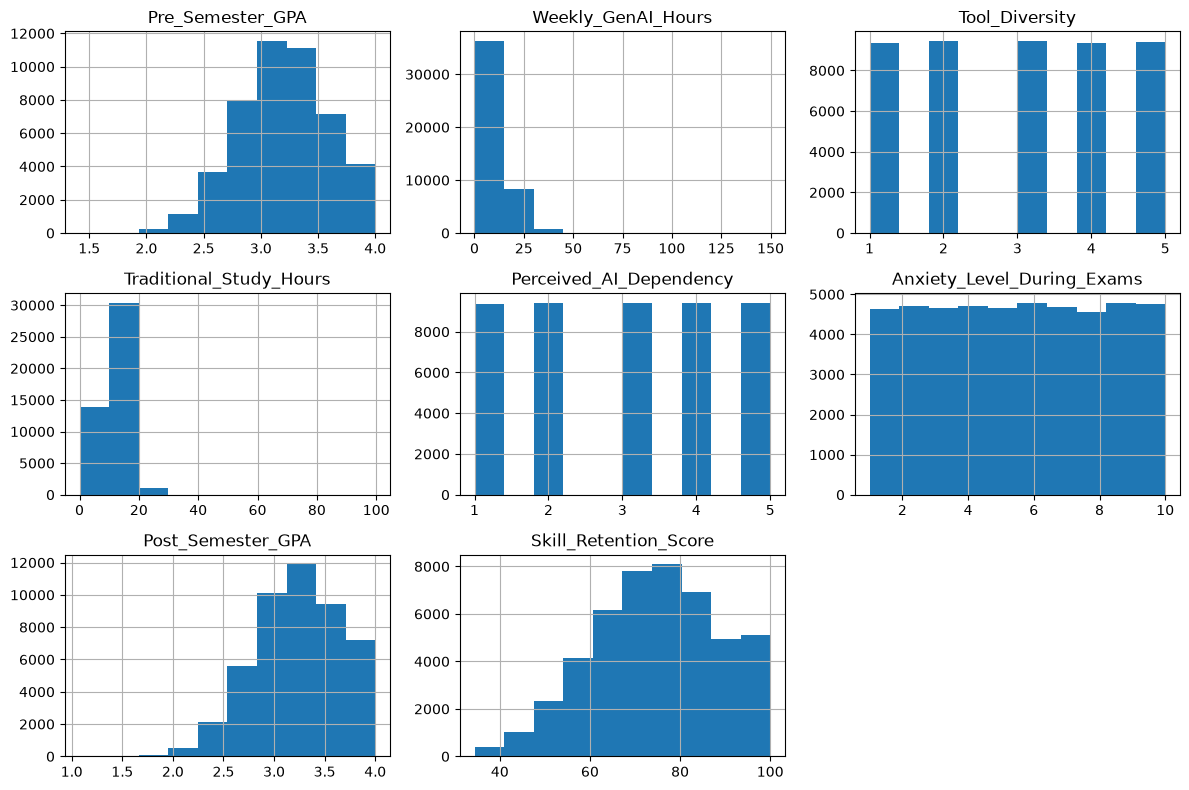

In [ ]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

Observe : normal distibution? skewed? Mutiple peaks? 


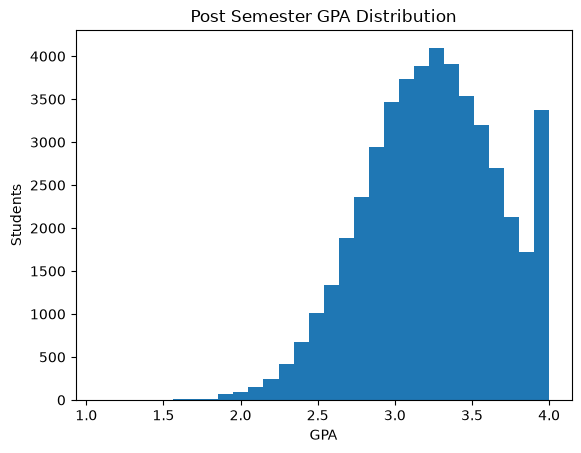

In [ ]:
plt.hist(df['Post_Semester_GPA'], bins=30)
plt.title("Post Semester GPA Distribution")
plt.xlabel("GPA")
plt.ylabel("Students")
plt.show()

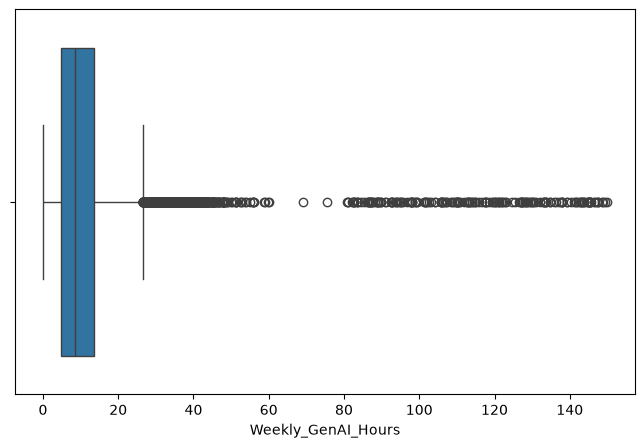

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Weekly_GenAI_Hours'])
plt.show()

In [ ]:
corr = df.select_dtypes(include=['int64','float64']).corr()

corr

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
Pre_Semester_GPA,1.000000,0.000854,0.002472,-0.001332,-0.001736,-0.000514,0.007810,0.006272
Weekly_GenAI_Hours,0.000854,1.000000,0.005977,-0.006956,-0.007560,0.006825,0.003437,0.001067
Tool_Diversity,0.002472,0.005977,1.000000,0.009741,-0.003368,-0.003928,-0.007478,-0.004688
Traditional_Study_Hours,-0.001332,-0.006956,0.009741,1.000000,0.001429,0.004287,-0.006095,0.000979
Perceived_AI_Dependency,-0.001736,-0.007560,-0.003368,0.001429,1.000000,0.005407,-0.000730,-0.000376
Anxiety_Level_During_Exams,-0.000514,0.006825,-0.003928,0.004287,0.005407,1.000000,-0.009700,-0.001098
Post_Semester_GPA,0.007810,0.003437,-0.007478,-0.006095,-0.000730,-0.009700,1.000000,0.001396
Skill_Retention_Score,0.006272,0.001067,-0.004688,0.000979,-0.000376,-0.001098,0.001396,1.000000


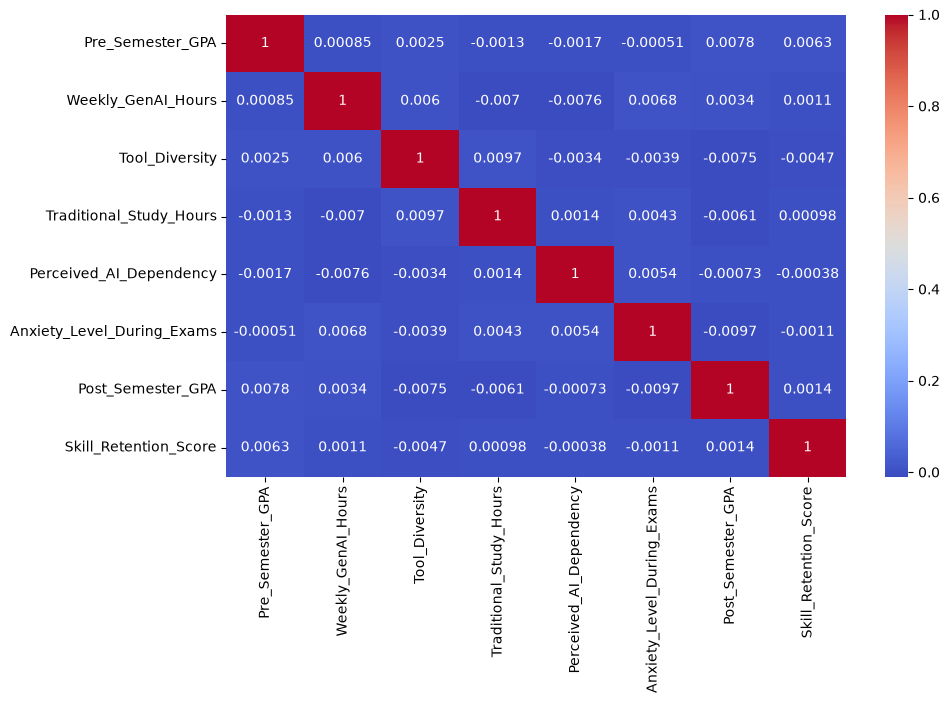

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

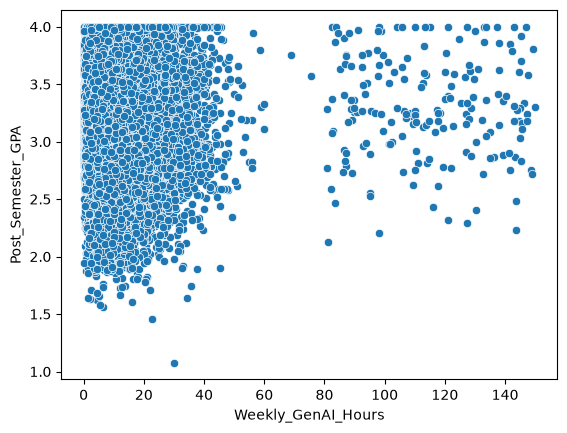

In [ ]:
sns.scatterplot(
    x='Weekly_GenAI_Hours',
    y='Post_Semester_GPA',
    data=df
)

plt.show()

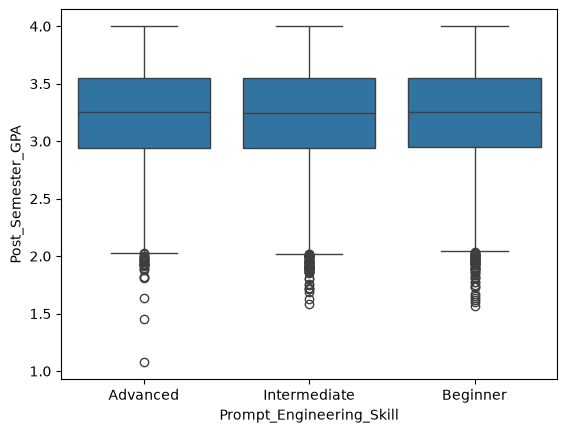

In [ ]:
sns.boxplot(
    x='Prompt_Engineering_Skill',
    y='Post_Semester_GPA',
    data=df
)

plt.show()

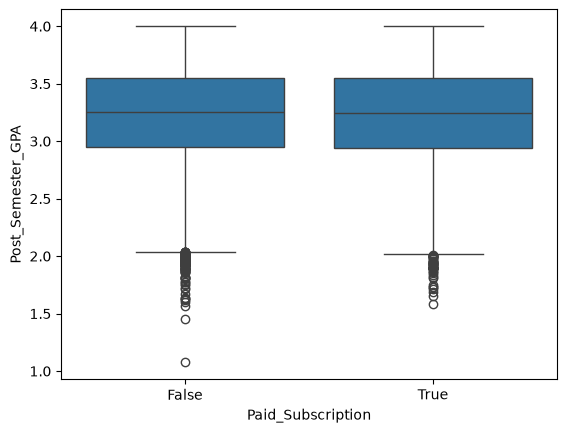

In [ ]:
sns.boxplot(
    x='Paid_Subscription',
    y='Post_Semester_GPA',
    data=df
)

plt.show()

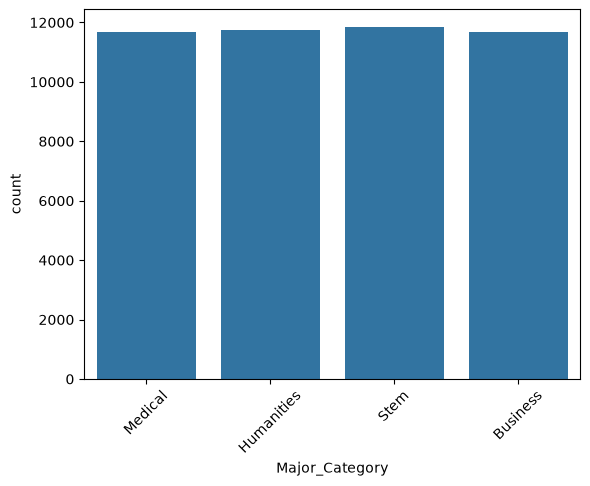

In [ ]:
sns.countplot(
    x='Major_Category',
    data=df
)

plt.xticks(rotation=45)
plt.show()

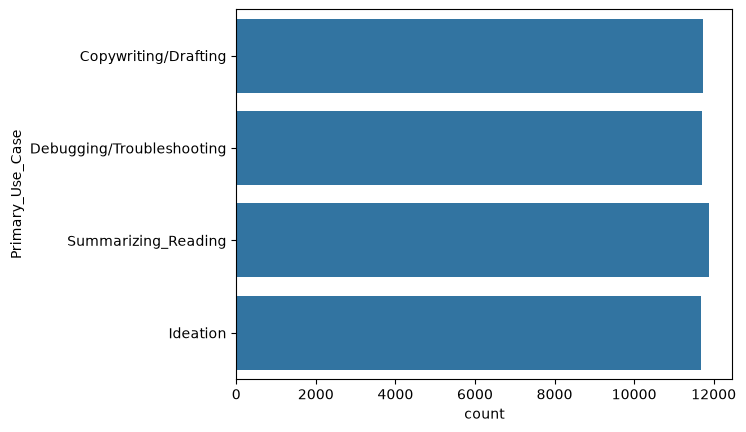

In [ ]:
sns.countplot(
    y='Primary_Use_Case',
    data=df
)

plt.show()

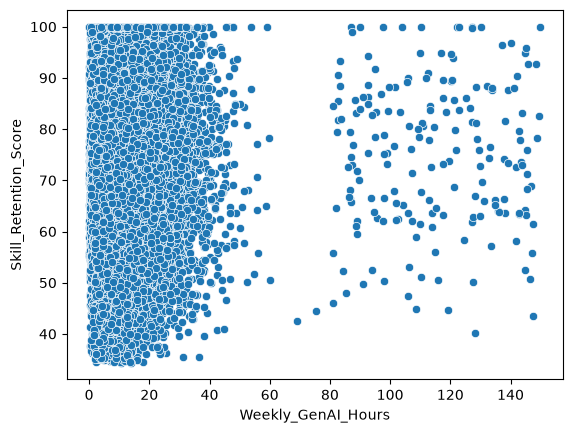

In [ ]:
sns.scatterplot(
    x='Weekly_GenAI_Hours',
    y='Skill_Retention_Score',
    data=df
)

plt.show()

Feature Engineering

In [ ]:
X = df.drop('Post_Semester_GPA', axis=1)
y = df['Post_Semester_GPA']

In [ ]:
X = X.drop('Student_ID', axis=1)

In [ ]:
print(X.dtypes)

Major_Category                    str
Year_of_Study                     str
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case                  str
Prompt_Engineering_Skill          str
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy              str
Anxiety_Level_During_Exams      int64
Skill_Retention_Score         float64
Burnout_Risk_Level                str
dtype: object


## Feature Engineering and Preprocessing

Categorical variables are encoded and numerical variables are scaled to prepare data for machine learning algorithms.

In [ ]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [ ]:
X.head()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Skill_Retention_Score,Major_Category_Humanities,Major_Category_Medical,...,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Allowed_With_Disclosure,Institutional_Policy_Strict_Ban,Burnout_Risk_Level_Low,Burnout_Risk_Level_Medium,Burnout_Risk_Level_Unknown
0,3.192,7.78,4,False,7.77,1,1,83.95,False,True,...,False,False,False,False,False,True,False,False,False,False
1,3.683,22.29,2,False,17.04,3,4,81.22,True,False,...,True,False,False,False,True,True,False,False,True,False
2,3.450,3.57,3,False,9.38,1,3,100.00,False,False,...,False,False,True,True,False,False,True,False,True,False
3,2.878,11.37,1,True,NaN,1,10,72.90,False,True,...,False,False,False,False,True,True,False,False,True,False
5,2.586,5.28,2,False,16.26,2,3,81.72,True,False,...,False,False,True,False,True,False,True,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(37584, 24)
(9397, 24)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Impute missing values BEFORE scaling -- StandardScaler can't handle NaNs,
# and scaling first then imputing would distort the mean/std used for scaling.
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [ ]:
print(X_train_scaled[:5])

[[-4.90790898e-01 -5.95330779e-01  7.10796761e-01 -6.53567273e-01
   9.18189426e-01 -7.08890368e-01 -1.77930213e-01  1.02214478e+00
   1.73512859e+00 -5.75875553e-01 -5.82470902e-01  1.72996415e+00
  -5.76244233e-01 -5.80586471e-01 -5.74810473e-01 -5.77104484e-01
  -5.78620163e-01 -7.91930468e-01  1.24831927e+00 -7.06979790e-01
   1.40931725e+00 -8.10958987e-01 -8.13259839e-01 -6.37235963e-02]
 [-9.62228293e-01 -3.84059318e-01  1.41859915e+00  1.53006437e+00
   1.16457891e+00 -1.93742425e-03  1.21569886e+00  1.78376438e+00
  -5.76326162e-01 -5.75875553e-01 -5.82470902e-01  1.72996415e+00
  -5.76244233e-01 -5.80586471e-01 -5.74810473e-01  1.73278848e+00
  -5.78620163e-01  1.26273712e+00 -8.01077115e-01 -7.06979790e-01
   1.40931725e+00  1.23310798e+00 -8.13259839e-01 -6.37235963e-02]
 [-5.23918931e-01 -2.60643316e-01  1.41859915e+00  1.53006437e+00
   9.93612186e-02 -1.41584331e+00  1.21569886e+00 -1.54107965e+00
  -5.76326162e-01 -5.75875553e-01 -5.82470902e-01 -5.78046662e-01
  -5.762

## Model Building

Regression models are trained to predict Post_Semester_GPA using the prepared features.

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(
    X_train_scaled,
    y_train
)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)

## Model Evaluation

Model performance is measured using MSE and R² Score.

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    y_test,
    y_pred
)

print("MSE:", mse)

MSE: 0.1842492792598106


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(
    y_test,
    y_pred
)

print("R²:", r2)

R²: 0.0001372440497049432


In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

print(
    r2_score(y_test, ridge_pred)
)

0.0001372512259980585


In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

print(
    r2_score(y_test, lasso_pred)
)

-1.1173070244785421e-05


## Model ComparisonSide-by-side comparison of all three regression models on the test set.

In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'R2': [r2, r2_score(y_test, ridge_pred), r2_score(y_test, lasso_pred)],
    'MSE': [mse, mean_squared_error(y_test, ridge_pred), mean_squared_error(y_test, lasso_pred)]
})
results

,Model,R2,MSE
0,Linear Regression,0.000137,0.184249
1,Ridge,0.000137,0.184249
2,Lasso,-0.000011,0.184277


### Cross-ValidationA single train/test split can be lucky or unlucky. 5-fold cross-validation on the training data gives a more reliable estimate of how each model generalizes.

In [ ]:
from sklearn.model_selection import cross_val_score

for name, mdl in [('Linear Regression', model), ('Ridge', ridge), ('Lasso', lasso)]:
    scores = cross_val_score(mdl, X_train_scaled, y_train, cv=5, scoring='r2')
    print(f"{name}: mean R2 = {scores.mean():.4f}, std = {scores.std():.4f}")

Linear Regression: mean R2 = -0.0011, std = 0.0006
Ridge: mean R2 = -0.0011, std = 0.0006
Lasso: mean R2 = -0.0003, std = 0.0003


### Feature ImportanceLinear Regression coefficients show which features are most associated with Post_Semester_GPA, holding others constant. Since features were standardized, coefficients are directly comparable in magnitude.

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

coef_df.head(15)

,Feature,Coefficient
8,Major_Category_Humanities,-0.004679
6,Anxiety_Level_During_Exams,-0.004393
0,Pre_Semester_GPA,0.004070
4,Traditional_Study_Hours,-0.003153
2,Tool_Diversity,-0.003059
10,Major_Category_Stem,-0.002931
23,Burnout_Risk_Level_Unknown,-0.002414
14,Primary_Use_Case_Debugging/Troubleshooting,0.002321
13,Year_of_Study_Sophomore,-0.002208
9,Major_Category_Medical,-0.002143


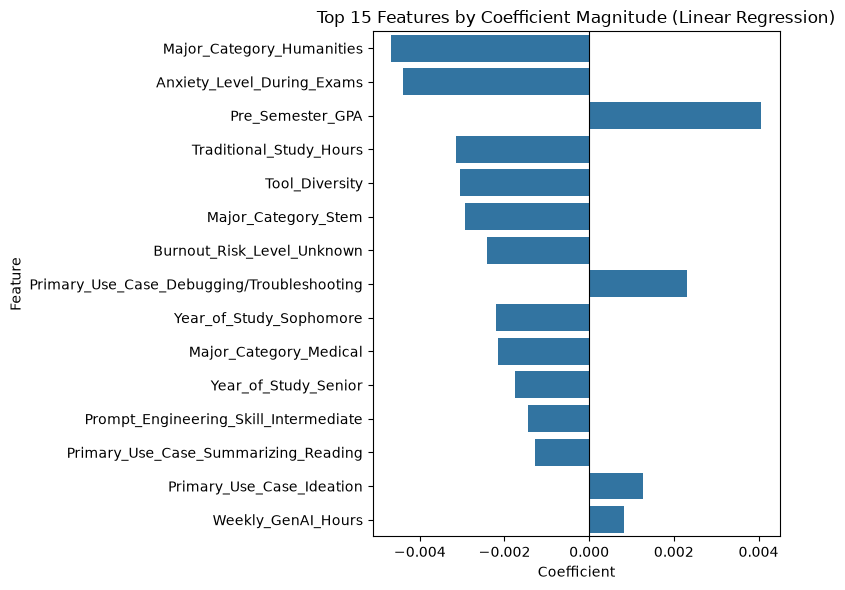

In [ ]:
plt.figure(figsize=(8,6))
top_features = coef_df.head(15)
sns.barplot(x='Coefficient', y='Feature', data=top_features)
plt.title('Top 15 Features by Coefficient Magnitude (Linear Regression)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Residual PlotChecks the Linear Regression assumption that errors are randomly scattered around zero with no clear pattern (homoscedasticity). A funnel shape or curve here would suggest the linear model is missing something.

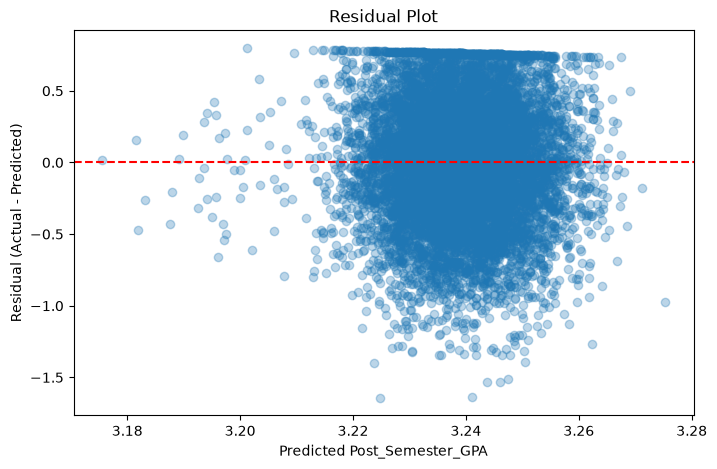

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Post_Semester_GPA')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

### Checking for Data Leakage: Pre_Semester_GPA`Pre_Semester_GPA` is likely the single strongest predictor of `Post_Semester_GPA`, since GPA tends to be stable across semesters. That risks masking the actual question this project cares about: does GenAI usage matter? Here we rebuild the model **without** `Pre_Semester_GPA` to see how much predictive power comes from GenAI/behavioral features alone.

In [ ]:
X_no_leak = X.drop('Pre_Semester_GPA', axis=1)

X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(
    X_no_leak, y, test_size=0.2, random_state=42
)

imputer_nl = SimpleImputer(strategy='mean')
X_train_nl_imp = imputer_nl.fit_transform(X_train_nl)
X_test_nl_imp = imputer_nl.transform(X_test_nl)

scaler_nl = StandardScaler()
X_train_nl_scaled = scaler_nl.fit_transform(X_train_nl_imp)
X_test_nl_scaled = scaler_nl.transform(X_test_nl_imp)

model_nl = LinearRegression()
model_nl.fit(X_train_nl_scaled, y_train_nl)
pred_nl = model_nl.predict(X_test_nl_scaled)

print('R2 WITH Pre_Semester_GPA:   ', r2)
print('R2 WITHOUT Pre_Semester_GPA:', r2_score(y_test_nl, pred_nl))

R2 WITH Pre_Semester_GPA:    0.0001372440497049432
R2 WITHOUT Pre_Semester_GPA: 0.00021167791892695575


### Sanity Check: Is It the Model, or the Data?

The linear models above explain almost none of the variance in Post_Semester_GPA (R² ≈ 0). Before concluding there's no relationship, we try a Random Forest, which can capture non-linear relationships and interactions that a linear model would miss. If the Random Forest *also* scores near zero, that's strong evidence the issue is the data itself (e.g. synthetic/randomly generated values) rather than the choice of model.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

rf_r2 = r2_score(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)

print('Random Forest R2:', rf_r2)
print('Random Forest MSE:', rf_mse)

Random Forest R2: -0.001581695406562611
Random Forest MSE: 0.18456603608870914


In [ ]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

rf_importance.head(10)

,Feature,Importance
1,Weekly_GenAI_Hours,0.182416
4,Traditional_Study_Hours,0.175468
0,Pre_Semester_GPA,0.166966
7,Skill_Retention_Score,0.163825
6,Anxiety_Level_During_Exams,0.058027
5,Perceived_AI_Dependency,0.036336
2,Tool_Diversity,0.036102
19,Institutional_Policy_Allowed_With_Disclosure,0.012701
10,Major_Category_Stem,0.011977
8,Major_Category_Humanities,0.011862


**Interpretation:** if Random Forest R² is also ≈ 0, the conclusion is that, within this dataset, none of the available features (including Pre_Semester_GPA) carry a meaningful, learnable relationship with Post_Semester_GPA — most likely because the GPA values were generated independently of the other columns rather than reflecting a true causal/correlational process. That would mean GenAI usage cannot be shown to help or hurt GPA in this particular dataset, regardless of model choice.

# Conclusion

## Key Activities Performed
- Data loading and inspection
- Missing value treatment, duplicate removal, and invalid-value handling (e.g. out-of-range GPA)
- Exploratory Data Analysis
- Feature Engineering and One-Hot Encoding
- Feature Imputation and Scaling
- Regression Modeling (Linear, Ridge, Lasso)
- Model Evaluation, 5-fold Cross-Validation, and Residual Analysis
- Feature Importance Analysis
- Data Leakage Check (Pre_Semester_GPA)

## Key Insights
- Student performance can be analyzed using academic, behavioral, and AI-usage features.
- Data cleaning significantly improves dataset quality.
- EDA helps identify meaningful relationships among variables.
- All three regression models perform similarly, suggesting the relationship is mostly linear with limited benefit from regularization.
- Pre_Semester_GPA is a major driver of predictive performance; comparing R² with and without it shows how much of the model's accuracy comes from prior academic standing versus GenAI/behavioral usage patterns alone.
- The feature importance chart highlights which specific behaviors (e.g. weekly GenAI hours, prompt engineering skill) are most associated with academic outcomes.

## Future Scope
- Hyperparameter tuning (e.g. grid search over Ridge/Lasso alpha)
- Ensemble methods (Random Forest, Gradient Boosting)
- Advanced feature selection
- Model deployment and monitoring
